In [1]:
import nlp
import requests
def download_file(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded: {filename}")
    else:
        print(f"Failed to download {url}")

# URLs of the parquet files
job_desc_url = "https://huggingface.co/datasets/lang-uk/recruitment-dataset-job-descriptions-english/resolve/main/data/train-00000-of-00001.parquet"
candidate_profile_url = "https://huggingface.co/datasets/lang-uk/recruitment-dataset-candidate-profiles-english/resolve/main/data/train-00000-of-00001.parquet"

# Download files
download_file(job_desc_url, "job_descriptions.parquet")
download_file(candidate_profile_url, "candidate_profiles.parquet")

/Users/prithvikumar/PycharmProjects/DijniResumeRanking/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/prithvikumar/PycharmProjects/DijniResumeRanking/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Downloaded: job_descriptions.parquet
Downloaded: candidate_profiles.parquet


In [2]:
!pip install pyarrow


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip show pyarrow

Name: pyarrow
Version: 21.0.0
Summary: Python library for Apache Arrow
Home-page: 
Author: 
Author-email: 
License: Apache Software License
Location: /Users/prithvikumar/PycharmProjects/DijniResumeRanking/.venv/lib/python3.9/site-packages
Requires: 
Required-by: nlp


In [4]:
import pandas as pd

job_df = pd.read_parquet("job_descriptions.parquet")
profile_df = pd.read_parquet("candidate_profiles.parquet")

In [5]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141897 entries, 0 to 141896
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Position               141897 non-null  object
 1   Long Description       141897 non-null  object
 2   Company Name           141897 non-null  object
 3   Exp Years              141897 non-null  object
 4   Primary Keyword        141897 non-null  object
 5   English Level          134358 non-null  object
 6   Published              141897 non-null  object
 7   Long Description_lang  141897 non-null  object
 8   id                     141897 non-null  object
 9   __index_level_0__      141897 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 10.8+ MB


In [6]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210250 entries, 0 to 210249
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Position           210250 non-null  object 
 1   Moreinfo           210250 non-null  object 
 2   Looking For        102055 non-null  object 
 3   Highlights         105529 non-null  object 
 4   Primary Keyword    210207 non-null  object 
 5   English Level      209765 non-null  object 
 6   Experience Years   210250 non-null  float64
 7   CV                 210250 non-null  object 
 8   CV_lang            210250 non-null  object 
 9   id                 210250 non-null  object 
 10  __index_level_0__  210250 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 17.6+ MB


In [7]:
profile_df.head()

,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__
0,"13 years of exp || Solidity, C#, JavaScript ||...",Who am I:\r\n- 13 years of commercial experien...,I am interested in:\r\n- part-time engagement;...,Landed a role of Director of Blockchain Develo...,Lead,fluent,11.0,Landed a role of Director of Blockchain Develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230
1,1c Developer,Worked on a mobile application for tracking trips,None,None,Other,intermediate,3.0,\nWorked on a mobile application for tracking ...,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231
2,1C developer,1 am an 1C developer. I deployed an 1C to typo...,None,None,Flutter,intermediate,11.0,\n1 am an 1C developer. I deployed an 1C to ty...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232
3,1C Developer,Perfect knowledge of 1C:Enterprise Platform.\...,None,None,Other,intermediate,11.0,\nPerfect knowledge of 1C:Enterprise Platform...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233
4,#1 Customer Support Specialist,"Tech addicted, experienced customer support wi...",In terms of the nature of the Customer Support...,"thousands of resolved problems, also, thousand...",Support,fluent,2.5,"thousands of resolved problems, also, thousand...",en,3f201183-db58-5333-9139-74c16059dc4a,24234


In [8]:
job_df.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__
0,10 + Blockchain Nodes / Masternodes to set up,*Requirements*\r\n\r\nWe're looking for a long...,MyCointainer,2y,Sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent ne...",TechScout.tech,2y,.NET,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462
2,"10X Engineer (co-founder, #4 employee, USD 11-...",**Product**\r\nThe product is a live video cha...,Innoteka,5y,JavaScript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463
3,16 - Amazon Brand Manager,"Currently, TCM expanding its activities to Ukr...",FirstFive,2y,Marketing,upper,2022-01-01T00:00:00+02:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464
4,16 - Amazon Brand Manager,"Hello,\r\nWe, MIMIRB2B, are an outstaff compan...",MimirB2B,1y,Marketing,upper,2021-12-01T00:00:00+02:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465


## Cleaning Data



In [9]:
# Drop duplicate job descriptions
jobs_df_cleaned = job_df.drop_duplicates()

# Drop duplicate candidate profiles
cvs_df_cleaned = profile_df.drop_duplicates()

# Filter out rows with missing essential data in jobs_df
jobs_df_cleaned = jobs_df_cleaned.dropna(subset=['Long Description', 'Primary Keyword'])

# Filter out rows with missing essential data in cvs_df
cvs_df_cleaned = cvs_df_cleaned.dropna(subset=['Moreinfo', 'Primary Keyword'])

print("Shape of jobs_df after cleaning:", jobs_df_cleaned.shape)
print("Shape of cvs_df after cleaning:", cvs_df_cleaned.shape)

Shape of jobs_df after cleaning: (141897, 10)
Shape of cvs_df after cleaning: (210207, 11)


# converting to lowercase



In [10]:
# Convert relevant text columns to lowercase in jobs_df_cleaned
for col in ['Position', 'Long Description', 'Primary Keyword']:
    jobs_df_cleaned[col] = jobs_df_cleaned[col].str.lower()

# Convert relevant text columns to lowercase in cvs_df_cleaned
for col in ['Position', 'Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword', 'CV']:
    cvs_df_cleaned[col] = cvs_df_cleaned[col].str.lower()

print("Text columns in jobs_df_cleaned converted to lowercase.")
print("Text columns in cvs_df_cleaned converted to lowercase.")

Text columns in jobs_df_cleaned converted to lowercase.
Text columns in cvs_df_cleaned converted to lowercase.


In [11]:
jobs_df_cleaned.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__
0,10 + blockchain nodes / masternodes to set up,*requirements*\r\n\r\nwe're looking for a long...,MyCointainer,2y,sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461
1,10 .net developers (middle and senior level),"greetings! my name is maria, i am in urgent ne...",TechScout.tech,2y,.net,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462
2,"10x engineer (co-founder, #4 employee, usd 11-...",**product**\r\nthe product is a live video cha...,Innoteka,5y,javascript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463
3,16 - amazon brand manager,"currently, tcm expanding its activities to ukr...",FirstFive,2y,marketing,upper,2022-01-01T00:00:00+02:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464
4,16 - amazon brand manager,"hello,\r\nwe, mimirb2b, are an outstaff compan...",MimirB2B,1y,marketing,upper,2021-12-01T00:00:00+02:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465


In [12]:
cvs_df_cleaned.head()

,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__
0,"13 years of exp || solidity, c#, javascript ||...",who am i:\r\n- 13 years of commercial experien...,i am interested in:\r\n- part-time engagement;...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230
1,1c developer,worked on a mobile application for tracking trips,None,None,other,intermediate,3.0,\nworked on a mobile application for tracking ...,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231
2,1c developer,1 am an 1c developer. i deployed an 1c to typo...,None,None,flutter,intermediate,11.0,\n1 am an 1c developer. i deployed an 1c to ty...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232
3,1c developer,perfect knowledge of 1c:enterprise platform.\...,None,None,other,intermediate,11.0,\nperfect knowledge of 1c:enterprise platform...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233
4,#1 customer support specialist,"tech addicted, experienced customer support wi...",in terms of the nature of the customer support...,"thousands of resolved problems, also, thousand...",support,fluent,2.5,"thousands of resolved problems, also, thousand...",en,3f201183-db58-5333-9139-74c16059dc4a,24234


In [13]:
import re

# clean text by removing special characters and extra whitespace
def clean_text(text):
    if isinstance(text, str):
        # Remove non-alphanumeric characters (keeping spaces)
        text = re.sub(r'[^a-z0-9\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return text

# Apply cleaning to relevant text columns in jobs_df_cleaned
for col in ['Position', 'Long Description', 'Primary Keyword']:
    jobs_df_cleaned[col] = jobs_df_cleaned[col].apply(clean_text)

# Apply cleaning to relevant text columns in cvs_df_cleaned
for col in ['Position', 'Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword', 'CV']:
    cvs_df_cleaned[col] = cvs_df_cleaned[col].apply(clean_text)

print("Non-essential special characters and excess whitespace removed from text columns.")

Non-essential special characters and excess whitespace removed from text columns.


In [14]:
jobs_df_cleaned.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2022-01-01T00:00:00+02:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-12-01T00:00:00+02:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465


In [15]:
cvs_df_cleaned.head()

,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230
1,1c developer,worked on a mobile application for tracking trips,None,None,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,None,None,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232
3,1c developer,perfect knowledge of 1centerprise platform goo...,None,None,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,24234


# Normalize the 'Company Name', 'Primary Keyword', and 'Position' columns

In [16]:
# Finding unique values and counts in jobs_df_cleaned
print("Unique values in jobs_df_cleaned:")
for col in ['Company Name', 'Primary Keyword', 'Position']:
    unique_count = jobs_df_cleaned[col].nunique()
    print(f"'{col}': {unique_count} unique values")
    print(f"First 20 unique values in '{col}':")
    print(jobs_df_cleaned[col].unique()[:20])
    print("-" * 30)

# Finding unique values and counts in cvs_df_cleaned
print("\nUnique values in cvs_df_cleaned:")
for col in ['Primary Keyword', 'Position']:
    unique_count = cvs_df_cleaned[col].nunique()
    print(f"'{col}': {unique_count} unique values")
    print(f"First 20 unique values in '{col}':")
    print(cvs_df_cleaned[col].unique()[:20])
    print("-" * 30)

Unique values in jobs_df_cleaned:
'Company Name': 10894 unique values
First 20 unique values in 'Company Name':
['MyCointainer' 'TechScout.tech' 'Innoteka' 'FirstFive' 'MimirB2B'
 'Argument' 'Exadel' 'Perfectial' 'PLATMA' 'N-iX' 'iDeals Solutions'
 'SII UKRAINE' 'Art2Hire' 'CHI Software' 'EvaCodes' 'MeekoTeams'
 'Data Virtuality' 'Wildix' 'FluentPro' 'Viseven']
------------------------------
'Primary Keyword': 45 unique values
First 20 unique values in 'Primary Keyword':
['sysadmin' 'net' 'javascript' 'marketing' 'php' 'sales' 'data science'
 'python' 'java' 'product manager' 'devops' 'other' 'nodejs' 'c'
 'recruiter' 'support' 'sql' 'ruby' 'artist' 'design']
------------------------------
'Position': 60575 unique values
First 20 unique values in 'Position':
['10 blockchain nodes masternodes to set up'
 '10 net developers middle and senior level'
 '10x engineer cofounder 4 employee usd 1112k 14 equity'
 '16 amazon brand manager' '180601 php developer' '180603 sales manager'
 '180701 mi

In [17]:
print(f"jobs_df_cleaned unique primary keywords: {jobs_df_cleaned['Primary Keyword'].nunique()}")

jobs_df_cleaned unique primary keywords: 45


In [18]:
print(f"cvs_df_cleaned unique primary keywords: {cvs_df_cleaned['Primary Keyword'].nunique()}")

cvs_df_cleaned unique primary keywords: 41


In [19]:
# Analyze 'Company Name' in jobs_df_cleaned
print(f"jobs_df_cleaned unique company names: {jobs_df_cleaned['Company Name'].nunique()}")

jobs_df_cleaned unique company names: 10894


In [20]:
# Analyze 'Position' in jobs_df_cleaned and cvs_df_cleaned
print("\n'Position' Column:")
print(f"jobs_df_cleaned unique positions: {jobs_df_cleaned['Position'].nunique()}")
print(f"cvs_df_cleaned unique positions: {cvs_df_cleaned['Position'].nunique()}")


'Position' Column:
jobs_df_cleaned unique positions: 60575
cvs_df_cleaned unique positions: 41514


In [21]:
%pip install fuzzywuzzy python-Levenshtein


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
from fuzzywuzzy import process
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk
import numpy as np

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt_tab')
try:
    nltk.data.find('corpora/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [25]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character used by WordNetLemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    if isinstance(text, str):
        return ' '.join([lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in nltk.word_tokenize(text)])
    return text

In [26]:
# 1. Normalize 'Primary Keyword'
# Manual mapping for common variations
keyword_mapping = {
    'net': '.net',
    'qa': 'quality assurance',
    'ba': 'business analyst',
    'ux/ui': 'ui/ux',
    'js': 'javascript',
    'php': 'php developer',
    'c#': 'c# developer',
    'c++': 'c++ developer',
    'golang': 'go developer',
    'hr': 'human resources',
    'pr': 'public relations',
    'seo': 'search engine optimization',
    'smm': 'social media marketing',
    'devops': 'devops engineer',
    'sysadmin': 'system administrator',
    'bi': 'business intelligence',
    'erp': 'enterprise resource planning',
    'crm': 'customer relationship management'
}

def normalize_keyword(keyword):
    if isinstance(keyword, str):
        keyword = keyword.strip()
        # Check for exact match in mapping
        if keyword in keyword_mapping:
            return keyword_mapping[keyword]
        # Simple fuzzy matching for close variations
        best_match, score = process.extractOne(keyword, keyword_mapping.keys())
        if score >= 90: # Use a high threshold for keywords
            return keyword_mapping[best_match]
    return keyword # Return original if no good match

jobs_df_cleaned['Primary Keyword Normalized'] = jobs_df_cleaned['Primary Keyword'].apply(normalize_keyword)
cvs_df_cleaned['Primary Keyword Normalized'] = cvs_df_cleaned['Primary Keyword'].apply(normalize_keyword)

In [27]:
# 2. Normalize 'Company Name' in jobs_df_cleaned using fuzzy matching
company_names = jobs_df_cleaned['Company Name'].tolist()
# Remove None/NaN values before processing
company_names = [name for name in company_names if isinstance(name, str) and name.strip()]
unique_company_names = list(set(company_names))

In [28]:
# Group similar company names (this can be computationally intensive)
# A simpler approach for demonstration is to create a mapping for top frequent names
# For a full implementation, clustering or more advanced record linkage is needed.
# Here, we'll demonstrate with a small sample or top names.
# If you need to process all names, consider using a more scalable library or approach.

# Let's process a sample or top names for demonstration
top_n_companies = jobs_df_cleaned['Company Name'].value_counts().nlargest(500).index.tolist() # Adjust N as needed
company_mapping = {}
processed_companies = set()

for name in top_n_companies:
    if name not in processed_companies:
        # Find similar names (adjust score threshold as needed)
        similar_names = process.extractBests(name, unique_company_names, score_cutoff=85) # Adjust threshold
        # Map all similar names to the most frequent or the current name
        canonical_name = name # Or choose the most frequent among similar_names
        for similar_name, score in similar_names:
            company_mapping[similar_name] = canonical_name
            processed_companies.add(similar_name)

# Apply the mapping to the DataFrame
jobs_df_cleaned['Company Name Normalized'] = jobs_df_cleaned['Company Name'].apply(lambda x: company_mapping.get(x, x))

In [29]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [30]:
# 3. Normalize 'Position' using text processing and clustering
# Combine positions from both dataframes for consistent normalization
all_positions = pd.concat([jobs_df_cleaned['Position'], cvs_df_cleaned['Position']]).unique()
all_positions = [pos for pos in all_positions if isinstance(pos, str) and pos.strip()] # Filter out empty strings

# Lemmatize positions
lemmatized_positions = [lemmatize_text(pos) for pos in all_positions]

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000) # Adjust max_features
tfidf_matrix = vectorizer.fit_transform(lemmatized_positions)

In [31]:
# Clustering (KMeans for demonstration, number of clusters is a hyperparameter)
# Determining the optimal number of clusters is complex and data-dependent.
# For this task, we'll choose a reasonable number or use a threshold-based grouping later.
# Let's try a smaller number of clusters for demonstration.
n_clusters = 500 # This needs careful tuning based on data and desired granularity
if tfidf_matrix.shape[0] > n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(tfidf_matrix)
    labels = kmeans.labels_

    # Create a mapping from original position to cluster label
    position_to_label = dict(zip(all_positions, labels))

    # Determine a representative title for each cluster (e.g., the most frequent or the centroid's closest title)
    # For simplicity, let's pick the first title in the cluster's list of original titles
    label_to_representative_position = {}
    for original_pos, label in position_to_label.items():
        if label not in label_to_representative_position:
            label_to_representative_position[label] = original_pos # This is a simplification

    # Apply the position normalization
    jobs_df_cleaned['Position Normalized'] = jobs_df_cleaned['Position'].apply(lambda x: label_to_representative_position.get(position_to_label.get(x, -1), x)) # Handle positions not in all_positions
    cvs_df_cleaned['Position Normalized'] = cvs_df_cleaned['Position'].apply(lambda x: label_to_representative_position.get(position_to_label.get(x, -1), x)) # Handle positions not in all_positions
else:
    print("Not enough unique positions to perform clustering with the specified number of clusters.")
    jobs_df_cleaned['Position Normalized'] = jobs_df_cleaned['Position']
    cvs_df_cleaned['Position Normalized'] = cvs_df_cleaned['Position']


# Review samples of normalized data
print("\nSample of Normalized 'Primary Keyword' in jobs_df_cleaned:")
display(jobs_df_cleaned[['Primary Keyword', 'Primary Keyword Normalized']].head())

print("\nSample of Normalized 'Primary Keyword' in cvs_df_cleaned:")
display(cvs_df_cleaned[['Primary Keyword', 'Primary Keyword Normalized']].head())

print("\nSample of Normalized 'Company Name' in jobs_df_cleaned:")
display(jobs_df_cleaned[['Company Name', 'Company Name Normalized']].head())

print("\nSample of Normalized 'Position' in jobs_df_cleaned:")
display(jobs_df_cleaned[['Position', 'Position Normalized']].head())

print("\nSample of Normalized 'Position' in cvs_df_cleaned:")
display(cvs_df_cleaned[['Position', 'Position Normalized']].head())


Sample of Normalized 'Primary Keyword' in jobs_df_cleaned:


,Primary Keyword,Primary Keyword Normalized
0,sysadmin,system administrator
1,net,.net
2,javascript,javascript
3,marketing,marketing
4,marketing,marketing



Sample of Normalized 'Primary Keyword' in cvs_df_cleaned:


,Primary Keyword,Primary Keyword Normalized
0,lead,lead
1,other,other
2,flutter,flutter
3,other,other
4,support,support



Sample of Normalized 'Company Name' in jobs_df_cleaned:


,Company Name,Company Name Normalized
0,MyCointainer,MyCointainer
1,TechScout.tech,TechScout.tech
2,Innoteka,Innoteka
3,FirstFive,FirstFive
4,MimirB2B,MimirB2B



Sample of Normalized 'Position' in jobs_df_cleaned:


,Position,Position Normalized
0,10 blockchain nodes masternodes to set up,10 blockchain nodes masternodes to set up
1,10 net developers middle and senior level,10 net developers middle and senior level
2,10x engineer cofounder 4 employee usd 1112k 14...,10x engineer cofounder 4 employee usd 1112k 14...
3,16 amazon brand manager,16 amazon brand manager
4,16 amazon brand manager,16 amazon brand manager



Sample of Normalized 'Position' in cvs_df_cleaned:


,Position,Position Normalized
0,13 years of exp solidity c javascript cto vp t...,cto vp of software development
1,1c developer,10x engineer cofounder 4 employee usd 1112k 14...
2,1c developer,10x engineer cofounder 4 employee usd 1112k 14...
3,1c developer,10x engineer cofounder 4 employee usd 1112k 14...
4,1 customer support specialist,accountingimmigration support specialist


In [32]:
# Display a random sample of 10 rows from jobs_df_cleaned
print("Random Sample of Normalized Data from jobs_df_cleaned:")
display(jobs_df_cleaned[['Primary Keyword', 'Primary Keyword Normalized', 'Company Name', 'Company Name Normalized', 'Position', 'Position Normalized']].sample(10, random_state=42))

# Display a random sample of 10 rows from cvs_df_cleaned
print("\nRandom Sample of Normalized Data from cvs_df_cleaned:")
display(cvs_df_cleaned[['Primary Keyword', 'Primary Keyword Normalized', 'Position', 'Position Normalized']].sample(10, random_state=42))

Random Sample of Normalized Data from jobs_df_cleaned:


,Primary Keyword,Primary Keyword Normalized,Company Name,Company Name Normalized,Position,Position Normalized
138255,design,design,GlobalLogic,GlobalLogic,trainee visual interaction designer,2d artistgraphic designer
29788,java,java,Ciklum,Ciklum,expert java developer for ciklum digital,agile delivery manager for ciklum digital
140542,data science,data science,42DM,42DM,web analyst,204502 middle python web developer
96207,qa automation,quality assurance,Valtech,Valtech,qa automation manual qa engineer,automation and manual qa engineer
118230,javascript,javascript,Independent Contractor,Independent Contractor,senior js react engineer,equities senior frontend developer react
89392,java,java,IdeaSoft,IdeaSoft,principal java engineer,application architect or principal software en...
66338,other,other,Mongrov,Mongrov,mern stack developer,200425 middle full stack developer
83756,other,other,Solid English School,Solid English School,native speaker it,advanced software engineer react native
95187,qa,quality assurance,Virtuace,Virtuace,qa analyst,abm analyst
66827,java,java,Job Advice Agency,Job Advice Agency,middle and senior java developer with german a...,account executive german language



Random Sample of Normalized Data from cvs_df_cleaned:


,Primary Keyword,Primary Keyword Normalized,Position,Position Normalized
43556,javascript,javascript,frontend developer,63 frontend developer
74613,javascript,javascript,javascript developer,54 senior javascript frontend developer with a...
123878,php,php developer,phpnodejs developer,10x engineer cofounder 4 employee usd 1112k 14...
197464,design,design,uiux designer,ambitious junior uiux designer
135701,project manager,public relations,project manager,administrative project manager
126067,product manager,public relations,product lead project manager,middlesenior product project manager
132644,project manager,public relations,project manager,administrative project manager
185954,python,python,strong junior python developer,android developer strong middle
3067,marketing,marketing,affiliate team leadsenior affiliate manager ig...,account affiliate manager
52248,nodejs,javascript,full stack web developer,expert full stack web developer


In [33]:
jobs_df_cleaned.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,Primary Keyword Normalized,Company Name Normalized,Position Normalized
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,system administrator,MyCointainer,10 blockchain nodes masternodes to set up
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,.net,TechScout.tech,10 net developers middle and senior level
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,javascript,Innoteka,10x engineer cofounder 4 employee usd 1112k 14...
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2022-01-01T00:00:00+02:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,marketing,FirstFive,16 amazon brand manager
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-12-01T00:00:00+02:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,marketing,MimirB2B,16 amazon brand manager


# Identifing Missing values

In [34]:
# Calculate missing values for jobs_df_cleaned
jobs_missing_values = jobs_df_cleaned.isnull().sum()

# Print missing values for jobs_df_cleaned
print("Missing values in jobs_df_cleaned:")
print(jobs_missing_values)

# Calculate missing values for cvs_df_cleaned
cvs_missing_values = cvs_df_cleaned.isnull().sum()

# Print missing values for cvs_df_cleaned
print("\nMissing values in cvs_df_cleaned:")
print(cvs_missing_values)

Missing values in jobs_df_cleaned:
Position                         0
Long Description                 0
Company Name                     0
Exp Years                        0
Primary Keyword                  0
English Level                 7539
Published                        0
Long Description_lang            0
id                               0
__index_level_0__                0
Primary Keyword Normalized       0
Company Name Normalized          0
Position Normalized              0
dtype: int64

Missing values in cvs_df_cleaned:
Position                           0
Moreinfo                           0
Looking For                   108173
Highlights                    104706
Primary Keyword                    0
English Level                    481
Experience Years                   0
CV                                 0
CV_lang                            0
id                                 0
__index_level_0__                  0
Primary Keyword Normalized         0
Position Normalize

In [35]:
# Impute missing 'English Level' in jobs_df_cleaned with "Unknown"
jobs_df_cleaned['English Level'] = jobs_df_cleaned['English Level'].fillna("Unknown")

# Impute missing 'English Level', 'Looking For', and 'Highlights' in cvs_df_cleaned with "Unknown"
cvs_df_cleaned['English Level'] = cvs_df_cleaned['English Level'].fillna("Unknown")
cvs_df_cleaned['Looking For'] = cvs_df_cleaned['Looking For'].fillna("Unknown")
cvs_df_cleaned['Highlights'] = cvs_df_cleaned['Highlights'].fillna("Unknown")

print("Missing values in specified categorical columns have been imputed with 'Unknown'.")

Missing values in specified categorical columns have been imputed with 'Unknown'.


In [36]:
# Verify missing values after imputation for jobs_df_cleaned
jobs_missing_values_after_imputation = jobs_df_cleaned.isnull().sum()
print("Missing values in jobs_df_cleaned after imputation:")
print(jobs_missing_values_after_imputation)

# Verify missing values after imputation for cvs_df_cleaned
cvs_missing_values_after_imputation = cvs_df_cleaned.isnull().sum()
print("\nMissing values in cvs_df_cleaned after imputation:")
print(cvs_missing_values_after_imputation)

Missing values in jobs_df_cleaned after imputation:
Position                      0
Long Description              0
Company Name                  0
Exp Years                     0
Primary Keyword               0
English Level                 0
Published                     0
Long Description_lang         0
id                            0
__index_level_0__             0
Primary Keyword Normalized    0
Company Name Normalized       0
Position Normalized           0
dtype: int64

Missing values in cvs_df_cleaned after imputation:
Position                      0
Moreinfo                      0
Looking For                   0
Highlights                    0
Primary Keyword               0
English Level                 0
Experience Years              0
CV                            0
CV_lang                       0
id                            0
__index_level_0__             0
Primary Keyword Normalized    0
Position Normalized           0
dtype: int64


# Impute missing values in numerical columns (like 'Experience Years') with the median or mean.


        Calculate the median of the 'Experience Years' column in cvs_df_cleaned and then impute the missing values with this median. Finally, verify the imputation by checking for null values in        that column.

In [37]:
# Calculate the median of 'Experience Years' in cvs_df_cleaned
median_experience_years = cvs_df_cleaned['Experience Years'].median()

# Impute missing values in 'Experience Years' with the median
cvs_df_cleaned['Experience Years'] = cvs_df_cleaned['Experience Years'].fillna(median_experience_years)

# Verify that there are no missing values in 'Experience Years'
print("\nMissing values in cvs_df_cleaned after imputing 'Experience Years':")
print(cvs_df_cleaned['Experience Years'].isnull().sum())


Missing values in cvs_df_cleaned after imputing 'Experience Years':
0


In [38]:
jobs_missing_per_row = jobs_df_cleaned.isnull().sum(axis=1)
cvs_missing_per_row = cvs_df_cleaned.isnull().sum(axis=1)

print(jobs_missing_per_row)
print(cvs_missing_per_row)


0         0
1         0
2         0
3         0
4         0
         ..
141892    0
141893    0
141894    0
141895    0
141896    0
Length: 141897, dtype: int64
0         0
1         0
2         0
3         0
4         0
         ..
210245    0
210246    0
210247    0
210248    0
210249    0
Length: 210207, dtype: int64


In [39]:
print("Columns in jobs_df_cleaned:")
print(jobs_df_cleaned.columns)
print("\nFirst 5 rows of jobs_df_cleaned:")
display(jobs_df_cleaned.head())

print("\nColumns in cvs_df_cleaned:")
print(cvs_df_cleaned.columns)
print("\nFirst 5 rows of cvs_df_cleaned:")
display(cvs_df_cleaned.head())

Columns in jobs_df_cleaned:
Index(['Position', 'Long Description', 'Company Name', 'Exp Years',
       'Primary Keyword', 'English Level', 'Published',
       'Long Description_lang', 'id', '__index_level_0__',
       'Primary Keyword Normalized', 'Company Name Normalized',
       'Position Normalized'],
      dtype='object')

First 5 rows of jobs_df_cleaned:


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,Primary Keyword Normalized,Company Name Normalized,Position Normalized
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,system administrator,MyCointainer,10 blockchain nodes masternodes to set up
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,.net,TechScout.tech,10 net developers middle and senior level
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,javascript,Innoteka,10x engineer cofounder 4 employee usd 1112k 14...
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2022-01-01T00:00:00+02:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,marketing,FirstFive,16 amazon brand manager
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-12-01T00:00:00+02:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,marketing,MimirB2B,16 amazon brand manager



Columns in cvs_df_cleaned:
Index(['Position', 'Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword',
       'English Level', 'Experience Years', 'CV', 'CV_lang', 'id',
       '__index_level_0__', 'Primary Keyword Normalized',
       'Position Normalized'],
      dtype='object')

First 5 rows of cvs_df_cleaned:


,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__,Primary Keyword Normalized,Position Normalized
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230,lead,cto vp of software development
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231,other,10x engineer cofounder 4 employee usd 1112k 14...
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232,flutter,10x engineer cofounder 4 employee usd 1112k 14...
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233,other,10x engineer cofounder 4 employee usd 1112k 14...
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,24234,support,accountingimmigration support specialist


In [40]:
jobs_df_cleaned['Published'] = pd.to_datetime(jobs_df_cleaned['Published'], errors='coerce',utc=True)
print("The 'Published' column in jobs_df_cleaned has been converted to datetime objects.")
jobs_df_cleaned.info()

The 'Published' column in jobs_df_cleaned has been converted to datetime objects.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141897 entries, 0 to 141896
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   Position                    141897 non-null  object             
 1   Long Description            141897 non-null  object             
 2   Company Name                141897 non-null  object             
 3   Exp Years                   141897 non-null  object             
 4   Primary Keyword             141897 non-null  object             
 5   English Level               141897 non-null  object             
 6   Published                   141897 non-null  datetime64[ns, UTC]
 7   Long Description_lang       141897 non-null  object             
 8   id                          141897 non-null  object             
 9   __index_level_0__           1418

In [41]:
jobs_df_cleaned['Published'] = pd.to_datetime(jobs_df_cleaned['Published'], errors='coerce', utc=True)
print("The 'Published' column in jobs_df_cleaned has been converted to datetime objects (UTC).")
jobs_df_cleaned.info()

The 'Published' column in jobs_df_cleaned has been converted to datetime objects (UTC).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141897 entries, 0 to 141896
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   Position                    141897 non-null  object             
 1   Long Description            141897 non-null  object             
 2   Company Name                141897 non-null  object             
 3   Exp Years                   141897 non-null  object             
 4   Primary Keyword             141897 non-null  object             
 5   English Level               141897 non-null  object             
 6   Published                   141897 non-null  datetime64[ns, UTC]
 7   Long Description_lang       141897 non-null  object             
 8   id                          141897 non-null  object             
 9   __index_level_0__         

In [42]:
# Extract the year from the 'Published' column
jobs_df_cleaned['posting_year'] = jobs_df_cleaned['Published'].dt.year

# Extract the month from the 'Published' column
jobs_df_cleaned['posting_month'] = jobs_df_cleaned['Published'].dt.month

In [43]:
# Display the first few rows of jobs_df_cleaned to inspect the new temporal columns
print("First 5 rows of jobs_df_cleaned with new temporal features:")
display(jobs_df_cleaned.head())

# Check the data types of columns in jobs_df_cleaned
print("\nInfo of jobs_df_cleaned:")
jobs_df_cleaned.info()

# Display the first few rows of cvs_df_cleaned to confirm no new temporal columns were added
print("\nFirst 5 rows of cvs_df_cleaned:")
display(cvs_df_cleaned.head())

# Check the data types of columns in cvs_df_cleaned
print("\nInfo of cvs_df_cleaned:")
cvs_df_cleaned.info()

First 5 rows of jobs_df_cleaned with new temporal features:


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,Primary Keyword Normalized,Company Name Normalized,Position Normalized,posting_year,posting_month
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,system administrator,MyCointainer,10 blockchain nodes masternodes to set up,2020,9
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,.net,TechScout.tech,10 net developers middle and senior level,2022,2
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,javascript,Innoteka,10x engineer cofounder 4 employee usd 1112k 14...,2021,6
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,marketing,FirstFive,16 amazon brand manager,2021,12
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,marketing,MimirB2B,16 amazon brand manager,2021,11



Info of jobs_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141897 entries, 0 to 141896
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   Position                    141897 non-null  object             
 1   Long Description            141897 non-null  object             
 2   Company Name                141897 non-null  object             
 3   Exp Years                   141897 non-null  object             
 4   Primary Keyword             141897 non-null  object             
 5   English Level               141897 non-null  object             
 6   Published                   141897 non-null  datetime64[ns, UTC]
 7   Long Description_lang       141897 non-null  object             
 8   id                          141897 non-null  object             
 9   __index_level_0__           141897 non-null  int64              
 10  Primary Keyword No

,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__,Primary Keyword Normalized,Position Normalized
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230,lead,cto vp of software development
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231,other,10x engineer cofounder 4 employee usd 1112k 14...
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232,flutter,10x engineer cofounder 4 employee usd 1112k 14...
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233,other,10x engineer cofounder 4 employee usd 1112k 14...
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,24234,support,accountingimmigration support specialist



Info of cvs_df_cleaned:
<class 'pandas.core.frame.DataFrame'>
Index: 210207 entries, 0 to 210249
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Position                    210207 non-null  object 
 1   Moreinfo                    210207 non-null  object 
 2   Looking For                 210207 non-null  object 
 3   Highlights                  210207 non-null  object 
 4   Primary Keyword             210207 non-null  object 
 5   English Level               210207 non-null  object 
 6   Experience Years            210207 non-null  float64
 7   CV                          210207 non-null  object 
 8   CV_lang                     210207 non-null  object 
 9   id                          210207 non-null  object 
 10  __index_level_0__           210207 non-null  int64  
 11  Primary Keyword Normalized  210207 non-null  object 
 12  Position Normalized         210207 non-null  object 

In [44]:
# Identify potential skill-related columns in jobs_df_cleaned
jobs_skill_columns = ['Long Description', 'Primary Keyword', 'Position'] # Based on column names

# Identify potential skill-related columns in cvs_df_cleaned
cvs_skill_columns = ['Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword', 'CV', 'Position'] # Based on column names

print("Potential skill-related columns in jobs_df_cleaned:")
print(jobs_skill_columns)

print("\nPotential skill-related columns in cvs_df_cleaned:")
print(cvs_skill_columns)

Potential skill-related columns in jobs_df_cleaned:
['Long Description', 'Primary Keyword', 'Position']

Potential skill-related columns in cvs_df_cleaned:
['Moreinfo', 'Looking For', 'Highlights', 'Primary Keyword', 'CV', 'Position']


# Tokenize text

In [45]:
from nltk.tokenize import word_tokenize

# Tokenize skill-related columns in jobs_df_cleaned
for col in jobs_skill_columns:
    jobs_df_cleaned[f'{col}_tokens'] = jobs_df_cleaned[col].apply(lambda x: word_tokenize(str(x)) if pd.notnull(x) else [])

# Tokenize skill-related columns in cvs_df_cleaned
for col in cvs_skill_columns:
    cvs_df_cleaned[f'{col}_tokens'] = cvs_df_cleaned[col].apply(lambda x: word_tokenize(str(x)) if pd.notnull(x) else [])

print("Text in skill-related columns tokenized.")
jobs_df_cleaned.head() 
cvs_df_cleaned.head()

Text in skill-related columns tokenized.


,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__,Primary Keyword Normalized,Position Normalized,Moreinfo_tokens,Looking For_tokens,Highlights_tokens,Primary Keyword_tokens,CV_tokens,Position_tokens
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230,lead,cto vp of software development,"[who, am, i, 13, years, of, commercial, experi...","[i, am, interested, in, parttime, engagement, ...","[landed, a, role, of, director, of, blockchain...",[lead],"[landed, a, role, of, director, of, blockchain...","[13, years, of, exp, solidity, c, javascript, ..."
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231,other,10x engineer cofounder 4 employee usd 1112k 14...,"[worked, on, a, mobile, application, for, trac...",[Unknown],[Unknown],[other],"[worked, on, a, mobile, application, for, trac...","[1c, developer]"
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232,flutter,10x engineer cofounder 4 employee usd 1112k 14...,"[1, am, an, 1c, developer, i, deployed, an, 1c...",[Unknown],[Unknown],[flutter],"[1, am, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]"
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233,other,10x engineer cofounder 4 employee usd 1112k 14...,"[perfect, knowledge, of, 1centerprise, platfor...",[Unknown],[Unknown],[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]"
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,24234,support,accountingimmigration support specialist,"[tech, addicted, experienced, customer, suppor...","[in, terms, of, the, nature, of, the, customer...","[thousands, of, resolved, problems, also, thou...",[support],"[thousands, of, resolved, problems, also, thou...","[1, customer, support, specialist]"


In [46]:
print("First 5 rows of jobs_df_cleaned with tokenized columns:")
display(jobs_df_cleaned.head())

print("\nFirst 5 rows of cvs_df_cleaned with tokenized columns:")
display(cvs_df_cleaned.head())

First 5 rows of jobs_df_cleaned with tokenized columns:


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,Primary Keyword Normalized,Company Name Normalized,Position Normalized,posting_year,posting_month,Long Description_tokens,Primary Keyword_tokens,Position_tokens
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,system administrator,MyCointainer,10 blockchain nodes masternodes to set up,2020,9,"[requirements, were, looking, for, a, long, te...",[sysadmin],"[10, blockchain, nodes, masternodes, to, set, up]"
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,.net,TechScout.tech,10 net developers middle and senior level,2022,2,"[greetings, my, name, is, maria, i, am, in, ur...",[net],"[10, net, developers, middle, and, senior, level]"
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,javascript,Innoteka,10x engineer cofounder 4 employee usd 1112k 14...,2021,6,"[product, the, product, is, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1..."
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,marketing,FirstFive,16 amazon brand manager,2021,12,"[currently, tcm, expanding, its, activities, t...",[marketing],"[16, amazon, brand, manager]"
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,marketing,MimirB2B,16 amazon brand manager,2021,11,"[hello, we, mimirb2b, are, an, outstaff, compa...",[marketing],"[16, amazon, brand, manager]"



First 5 rows of cvs_df_cleaned with tokenized columns:


,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,__index_level_0__,Primary Keyword Normalized,Position Normalized,Moreinfo_tokens,Looking For_tokens,Highlights_tokens,Primary Keyword_tokens,CV_tokens,Position_tokens
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,24230,lead,cto vp of software development,"[who, am, i, 13, years, of, commercial, experi...","[i, am, interested, in, parttime, engagement, ...","[landed, a, role, of, director, of, blockchain...",[lead],"[landed, a, role, of, director, of, blockchain...","[13, years, of, exp, solidity, c, javascript, ..."
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,24231,other,10x engineer cofounder 4 employee usd 1112k 14...,"[worked, on, a, mobile, application, for, trac...",[Unknown],[Unknown],[other],"[worked, on, a, mobile, application, for, trac...","[1c, developer]"
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,24232,flutter,10x engineer cofounder 4 employee usd 1112k 14...,"[1, am, an, 1c, developer, i, deployed, an, 1c...",[Unknown],[Unknown],[flutter],"[1, am, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]"
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,24233,other,10x engineer cofounder 4 employee usd 1112k 14...,"[perfect, knowledge, of, 1centerprise, platfor...",[Unknown],[Unknown],[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]"
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,24234,support,accountingimmigration support specialist,"[tech, addicted, experienced, customer, suppor...","[in, terms, of, the, nature, of, the, customer...","[thousands, of, resolved, problems, also, thou...",[support],"[thousands, of, resolved, problems, also, thou...","[1, customer, support, specialist]"


## Lemmatize tokens


In [47]:
def lemmatize_tokens(tokens):
    if isinstance(tokens, list):
        return [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in tokens]
    return []

# Apply lemmatization to tokenized skill columns in jobs_df_cleaned
for col in jobs_skill_columns:
    jobs_df_cleaned[f'{col}_lemmatized'] = jobs_df_cleaned[f'{col}_tokens'].apply(lemmatize_tokens)

# Apply lemmatization to tokenized skill columns in cvs_df_cleaned
for col in cvs_skill_columns:
    cvs_df_cleaned[f'{col}_lemmatized'] = cvs_df_cleaned[f'{col}_tokens'].apply(lemmatize_tokens)

print("Tokens in skill-related columns have been lemmatized.")

# Display the head of both dataframes to show the new lemmatized token columns
print("\nFirst 5 rows of jobs_df_cleaned with lemmatized columns:")
display(jobs_df_cleaned.head())

print("\nFirst 5 rows of cvs_df_cleaned with lemmatized columns:")
display(cvs_df_cleaned.head())

Tokens in skill-related columns have been lemmatized.

First 5 rows of jobs_df_cleaned with lemmatized columns:


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,...,Company Name Normalized,Position Normalized,posting_year,posting_month,Long Description_tokens,Primary Keyword_tokens,Position_tokens,Long Description_lemmatized,Primary Keyword_lemmatized,Position_lemmatized
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,...,MyCointainer,10 blockchain nodes masternodes to set up,2020,9,"[requirements, were, looking, for, a, long, te...",[sysadmin],"[10, blockchain, nodes, masternodes, to, set, up]","[requirement, be, look, for, a, long, term, co...",[sysadmin],"[10, blockchain, node, masternodes, to, set, up]"
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,...,TechScout.tech,10 net developers middle and senior level,2022,2,"[greetings, my, name, is, maria, i, am, in, ur...",[net],"[10, net, developers, middle, and, senior, level]","[greeting, my, name, be, maria, i, be, in, urg...",[net],"[10, net, developer, middle, and, senior, level]"
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,...,Innoteka,10x engineer cofounder 4 employee usd 1112k 14...,2021,6,"[product, the, product, is, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, the, product, be, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1..."
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,...,FirstFive,16 amazon brand manager,2021,12,"[currently, tcm, expanding, its, activities, t...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, it, activity, to, ukr...",[marketing],"[16, amazon, brand, manager]"
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,...,MimirB2B,16 amazon brand manager,2021,11,"[hello, we, mimirb2b, are, an, outstaff, compa...",[marketing],"[16, amazon, brand, manager]","[hello, we, mimirb2b, be, an, outstaff, compan...",[marketing],"[16, amazon, brand, manager]"



First 5 rows of cvs_df_cleaned with lemmatized columns:


,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,...,Highlights_tokens,Primary Keyword_tokens,CV_tokens,Position_tokens,Moreinfo_lemmatized,Looking For_lemmatized,Highlights_lemmatized,Primary Keyword_lemmatized,CV_lemmatized,Position_lemmatized
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,...,"[landed, a, role, of, director, of, blockchain...",[lead],"[landed, a, role, of, director, of, blockchain...","[13, years, of, exp, solidity, c, javascript, ...","[who, be, i, 13, year, of, commercial, experie...","[i, be, interested, in, parttime, engagement, ...","[land, a, role, of, director, of, blockchain, ...",[lead],"[land, a, role, of, director, of, blockchain, ...","[13, year, of, exp, solidity, c, javascript, c..."
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,...,[Unknown],[other],"[worked, on, a, mobile, application, for, trac...","[1c, developer]","[work, on, a, mobile, application, for, track,...",[Unknown],[Unknown],[other],"[work, on, a, mobile, application, for, track,...","[1c, developer]"
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,...,[Unknown],[flutter],"[1, am, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]","[1, be, an, 1c, developer, i, deployed, an, 1c...",[Unknown],[Unknown],[flutter],"[1, be, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]"
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,...,[Unknown],[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]","[perfect, knowledge, of, 1centerprise, platfor...",[Unknown],[Unknown],[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]"
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,...,"[thousands, of, resolved, problems, also, thou...",[support],"[thousands, of, resolved, problems, also, thou...","[1, customer, support, specialist]","[tech, addict, experienced, customer, support,...","[in, term, of, the, nature, of, the, customer,...","[thousand, of, resolve, problem, also, thousan...",[support],"[thousand, of, resolve, problem, also, thousan...","[1, customer, support, specialist]"


In [48]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/prithvikumar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
from nltk.corpus import stopwords

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Define a function to remove stopwords from a list of tokens
def remove_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    return []

# Apply stopword removal to lemmatized skill columns in jobs_df_cleaned
for col in jobs_skill_columns:
    jobs_df_cleaned[f'{col}_lemmatized_nostop'] = jobs_df_cleaned[f'{col}_lemmatized'].apply(remove_stopwords)

# Apply stopword removal to lemmatized skill columns in cvs_df_cleaned
for col in cvs_skill_columns:
    cvs_df_cleaned[f'{col}_lemmatized_nostop'] = cvs_df_cleaned[f'{col}_lemmatized'].apply(remove_stopwords)

print("Stopwords removed from lemmatized skill-related columns.")

Stopwords removed from lemmatized skill-related columns.


In [50]:
# Display the head of both dataframes to show the new columns
print("\nFirst 5 rows of jobs_df_cleaned with stopwords removed:")
display(jobs_df_cleaned.head())

print("\nFirst 5 rows of cvs_df_cleaned with stopwords removed:")
display(cvs_df_cleaned.head())


First 5 rows of jobs_df_cleaned with stopwords removed:


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,...,posting_month,Long Description_tokens,Primary Keyword_tokens,Position_tokens,Long Description_lemmatized,Primary Keyword_lemmatized,Position_lemmatized,Long Description_lemmatized_nostop,Primary Keyword_lemmatized_nostop,Position_lemmatized_nostop
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,...,9,"[requirements, were, looking, for, a, long, te...",[sysadmin],"[10, blockchain, nodes, masternodes, to, set, up]","[requirement, be, look, for, a, long, term, co...",[sysadmin],"[10, blockchain, node, masternodes, to, set, up]","[requirement, look, long, term, collaboration,...",[sysadmin],"[10, blockchain, node, masternodes, set]"
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,...,2,"[greetings, my, name, is, maria, i, am, in, ur...",[net],"[10, net, developers, middle, and, senior, level]","[greeting, my, name, be, maria, i, be, in, urg...",[net],"[10, net, developer, middle, and, senior, level]","[greeting, name, maria, urgent, need, find, te...",[net],"[10, net, developer, middle, senior, level]"
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,...,6,"[product, the, product, is, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, the, product, be, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, product, live, video, chat, cobrowsi...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1..."
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,...,12,"[currently, tcm, expanding, its, activities, t...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, it, activity, to, ukr...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, activity, ukraine, hi...",[marketing],"[16, amazon, brand, manager]"
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,...,11,"[hello, we, mimirb2b, are, an, outstaff, compa...",[marketing],"[16, amazon, brand, manager]","[hello, we, mimirb2b, be, an, outstaff, compan...",[marketing],"[16, amazon, brand, manager]","[hello, mimirb2b, outstaff, company, look, exp...",[marketing],"[16, amazon, brand, manager]"



First 5 rows of cvs_df_cleaned with stopwords removed:


,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,...,Highlights_lemmatized,Primary Keyword_lemmatized,CV_lemmatized,Position_lemmatized,Moreinfo_lemmatized_nostop,Looking For_lemmatized_nostop,Highlights_lemmatized_nostop,Primary Keyword_lemmatized_nostop,CV_lemmatized_nostop,Position_lemmatized_nostop
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,...,"[land, a, role, of, director, of, blockchain, ...",[lead],"[land, a, role, of, director, of, blockchain, ...","[13, year, of, exp, solidity, c, javascript, c...","[13, year, commercial, experience, software, e...","[interested, parttime, engagement, blockchain,...","[land, role, director, blockchain, development...",[lead],"[land, role, director, blockchain, development...","[13, year, exp, solidity, c, javascript, cto, ..."
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,...,[Unknown],[other],"[work, on, a, mobile, application, for, track,...","[1c, developer]","[work, mobile, application, track, trip]",[Unknown],[Unknown],[],"[work, mobile, application, track, trip]","[1c, developer]"
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,...,[Unknown],[flutter],"[1, be, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]","[1, 1c, developer, deployed, 1c, typographical...",[Unknown],[Unknown],[flutter],"[1, 1c, developer, deployed, 1c, typographical...","[1c, developer]"
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,...,[Unknown],[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]","[perfect, knowledge, 1centerprise, platform, g...",[Unknown],[Unknown],[],"[perfect, knowledge, 1centerprise, platform, g...","[1c, developer]"
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,...,"[thousand, of, resolve, problem, also, thousan...",[support],"[thousand, of, resolve, problem, also, thousan...","[1, customer, support, specialist]","[tech, addict, experienced, customer, support,...","[term, nature, customer, support, position, lo...","[thousand, resolve, problem, also, thousand, h...",[support],"[thousand, resolve, problem, also, thousand, h...","[1, customer, support, specialist]"


In [51]:
# Identify potential columns containing organizations, certifications, and locations in jobs_df_cleaned
jobs_ner_columns = ['Position', 'Long Description', 'Company Name'] # 'Company Name' for organizations, 'Position' and 'Long Description' may contain certifications and locations

# Identify potential columns containing organizations, certifications, and locations in cvs_df_cleaned
cvs_ner_columns = ['Position', 'Moreinfo', 'Highlights', 'CV'] # These columns are most likely to contain mentions of organizations, certifications, and locations

print("Potential NER-related columns in jobs_df_cleaned:")
print(jobs_ner_columns)

print("\nPotential NER-related columns in cvs_df_cleaned:")
print(cvs_ner_columns)

Potential NER-related columns in jobs_df_cleaned:
['Position', 'Long Description', 'Company Name']

Potential NER-related columns in cvs_df_cleaned:
['Position', 'Moreinfo', 'Highlights', 'CV']


In [52]:
!pip install nlp

python(28741) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [53]:
!pip install spacy

python(28745) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [54]:
import spacy

# Load the English spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

In [57]:
def extract_entities(text):
    entities = {}
    if isinstance(text, str):
        doc = nlp(text)
        for ent in doc.ents:
            if ent.label_ not in entities:
                entities[ent.label_] = []
            entities[ent.label_].append(ent.text)
    return entities

In [58]:
jobs_df_cleaned['Extracted Entities'] = jobs_df_cleaned['Long Description'].apply(extract_entities)

# Apply NER to relevant text columns in cvs_df_cleaned
# 'Moreinfo' and 'CV' are good candidates for extracting various entities
cvs_df_cleaned['Extracted Entities'] = (cvs_df_cleaned['Moreinfo'].fillna('') + ' ' + cvs_df_cleaned['CV'].fillna('')).apply(extract_entities)


# Display samples of dataframes with the new 'Extracted Entities' columns
print("\nSample of jobs_df_cleaned with 'Extracted Entities':")
display(jobs_df_cleaned[['Long Description', 'Extracted Entities']].head())

print("\nSample of cvs_df_cleaned with 'Extracted Entities':")
display(cvs_df_cleaned[['Moreinfo', 'CV', 'Extracted Entities']].head())

# Optional: Examine the distribution of entity types
all_entity_types_jobs = set()
for entity_dict in jobs_df_cleaned['Extracted Entities']:
    all_entity_types_jobs.update(entity_dict.keys())

all_entity_types_cvs = set()
for entity_dict in cvs_df_cleaned['Extracted Entities']:
    all_entity_types_cvs.update(entity_dict.keys())

print("\nEntity types found in jobs_df_cleaned:")
print(sorted(list(all_entity_types_jobs)))

print("\nEntity types found in cvs_df_cleaned:")
print(sorted(list(all_entity_types_cvs)))


Sample of jobs_df_cleaned with 'Extracted Entities':


,Long Description,Extracted Entities
0,requirements were looking for a long term coll...,{}
1,greetings my name is maria i am in urgent need...,"{'CARDINAL': ['10', '30005000', '9'], 'DATE': ..."
2,product the product is a live video chat and c...,"{'DATE': ['5 months', '2 months ago', '5 month..."
3,currently tcm expanding its activities to ukra...,"{'DATE': ['daily', '2 years', 'daily'], 'CARDI..."
4,hello we mimirb2b are an outstaff company and ...,"{'DATE': ['daily', '2 years', 'daily'], 'CARDI..."



Sample of cvs_df_cleaned with 'Extracted Entities':


,Moreinfo,CV,Extracted Entities
0,who am i 13 years of commercial experience as ...,landed a role of director of blockchain develo...,"{'DATE': ['i 13 years', '5 years', '12 years',..."
1,worked on a mobile application for tracking trips,worked on a mobile application for tracking trips,{}
2,1 am an 1c developer i deployed an 1c to typog...,1 am an 1c developer i deployed an 1c to typog...,"{'QUANTITY': ['1 am an 1c'], 'CARDINAL': ['1c'..."
3,perfect knowledge of 1centerprise platform goo...,perfect knowledge of 1centerprise platform goo...,"{'CARDINAL': ['1centerprise', '1c', '1c', '1c'..."
4,tech addicted experienced customer support wit...,thousands of resolved problems also thousands ...,"{'DATE': ['2 years', 'years', '2 years', 'year..."



Entity types found in jobs_df_cleaned:
['CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART']

Entity types found in cvs_df_cleaned:
['CARDINAL', 'DATE', 'EVENT', 'FAC', 'GPE', 'LANGUAGE', 'LAW', 'LOC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PERCENT', 'PERSON', 'PRODUCT', 'QUANTITY', 'TIME', 'WORK_OF_ART']


In [65]:
# Save as Parquet (recommended)
jobs_df_cleaned.to_parquet("jobs_df_with_entities.parquet", engine="pyarrow",index=False)
cvs_df_cleaned.to_parquet("cvs_df_with_entities.parquet", engine="pyarrow",index=False)

In [66]:
# Load from Parquet
# jobs_df_cleaned = pd.read_parquet("jobs_df_with_entities.parquet", engine="pyarrow")
# cvs_df_cleaned = pd.read_parquet("cvs_df_with_entities.parquet", engine="pyarrow")
# print(jobs_df_cleaned.shape, cvs_df_cleaned.shape)
df_temp_jobs_df_cleaned = pd.read_parquet("jobs_df_with_entities.parquet", engine="pyarrow")
df_temp = pd.read_parquet("cvs_df_with_entities.parquet", engine="pyarrow")
df_temp = df_temp.reset_index(drop=True)

In [68]:
df_temp_jobs_df_cleaned = df_temp_jobs_df_cleaned.reset_index(drop=True)

In [69]:
df_temp_jobs_df_cleaned.head()

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,__index_level_0__,...,Long Description_tokens,Primary Keyword_tokens,Position_tokens,Long Description_lemmatized,Primary Keyword_lemmatized,Position_lemmatized,Long Description_lemmatized_nostop,Primary Keyword_lemmatized_nostop,Position_lemmatized_nostop,Extracted Entities
0,10 blockchain nodes masternodes to set up,requirements were looking for a long term coll...,MyCointainer,2y,sysadmin,intermediate,2020-09-30 21:00:00+00:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170,27461,...,"[requirements, were, looking, for, a, long, te...",[sysadmin],"[10, blockchain, nodes, masternodes, to, set, up]","[requirement, be, look, for, a, long, term, co...",[sysadmin],"[10, blockchain, node, masternodes, to, set, up]","[requirement, look, long, term, collaboration,...",[sysadmin],"[10, blockchain, node, masternodes, set]","{'CARDINAL': None, 'DATE': None, 'EVENT': None..."
1,10 net developers middle and senior level,greetings my name is maria i am in urgent need...,TechScout.tech,2y,net,intermediate,2022-02-28 22:00:00+00:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f,27462,...,"[greetings, my, name, is, maria, i, am, in, ur...",[net],"[10, net, developers, middle, and, senior, level]","[greeting, my, name, be, maria, i, be, in, urg...",[net],"[10, net, developer, middle, and, senior, level]","[greeting, name, maria, urgent, need, find, te...",[net],"[10, net, developer, middle, senior, level]","{'CARDINAL': ['10', '30005000', '9'], 'DATE': ..."
2,10x engineer cofounder 4 employee usd 1112k 14...,product the product is a live video chat and c...,Innoteka,5y,javascript,fluent,2021-06-30 21:00:00+00:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f,27463,...,"[product, the, product, is, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, the, product, be, a, live, video, ch...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","[product, product, live, video, chat, cobrowsi...",[javascript],"[10x, engineer, cofounder, 4, employee, usd, 1...","{'CARDINAL': ['7', '11', '15', '14', '4', '14'..."
3,16 amazon brand manager,currently tcm expanding its activities to ukra...,FirstFive,2y,marketing,upper,2021-12-31 22:00:00+00:00,en,99cb3f4a-9b4b-53d9-9a3b-bab2c22da346,27464,...,"[currently, tcm, expanding, its, activities, t...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, it, activity, to, ukr...",[marketing],"[16, amazon, brand, manager]","[currently, tcm, expand, activity, ukraine, hi...",[marketing],"[16, amazon, brand, manager]","{'CARDINAL': ['zero'], 'DATE': ['daily', '2 ye..."
4,16 amazon brand manager,hello we mimirb2b are an outstaff company and ...,MimirB2B,1y,marketing,upper,2021-11-30 22:00:00+00:00,en,bc1419f7-28e2-582b-8d53-22e28b2f0210,27465,...,"[hello, we, mimirb2b, are, an, outstaff, compa...",[marketing],"[16, amazon, brand, manager]","[hello, we, mimirb2b, be, an, outstaff, compan...",[marketing],"[16, amazon, brand, manager]","[hello, mimirb2b, outstaff, company, look, exp...",[marketing],"[16, amazon, brand, manager]","{'CARDINAL': ['zero'], 'DATE': ['daily', '2 ye..."


In [67]:
df_temp.head()

,Position,Moreinfo,Looking For,Highlights,Primary Keyword,English Level,Experience Years,CV,CV_lang,id,...,Primary Keyword_lemmatized,CV_lemmatized,Position_lemmatized,Moreinfo_lemmatized_nostop,Looking For_lemmatized_nostop,Highlights_lemmatized_nostop,Primary Keyword_lemmatized_nostop,CV_lemmatized_nostop,Position_lemmatized_nostop,Extracted Entities
0,13 years of exp solidity c javascript cto vp t...,who am i 13 years of commercial experience as ...,i am interested in parttime engagement blockch...,landed a role of director of blockchain develo...,lead,fluent,11.0,landed a role of director of blockchain develo...,en,50534b61-6826-52b1-9ac5-bfd2cfa348ec,...,[lead],"[land, a, role, of, director, of, blockchain, ...","[13, year, of, exp, solidity, c, javascript, c...","[13, year, commercial, experience, software, e...","[interested, parttime, engagement, blockchain,...","[land, role, director, blockchain, development...",[lead],"[land, role, director, blockchain, development...","[13, year, exp, solidity, c, javascript, cto, ...","{'CARDINAL': ['79', '6', '79', '6', '120', '12..."
1,1c developer,worked on a mobile application for tracking trips,Unknown,Unknown,other,intermediate,3.0,worked on a mobile application for tracking trips,en,c2b9ea56-b5c8-50ec-a63b-053a5c8ff467,...,[other],"[work, on, a, mobile, application, for, track,...","[1c, developer]","[work, mobile, application, track, trip]",[Unknown],[Unknown],[],"[work, mobile, application, track, trip]","[1c, developer]","{'CARDINAL': None, 'DATE': None, 'EVENT': None..."
2,1c developer,1 am an 1c developer i deployed an 1c to typog...,Unknown,Unknown,flutter,intermediate,11.0,1 am an 1c developer i deployed an 1c to typog...,en,b3bfe3ed-ec25-56b2-8aaa-8c629120538e,...,[flutter],"[1, be, an, 1c, developer, i, deployed, an, 1c...","[1c, developer]","[1, 1c, developer, deployed, 1c, typographical...",[Unknown],[Unknown],[flutter],"[1, 1c, developer, deployed, 1c, typographical...","[1c, developer]","{'CARDINAL': ['1c', '1c', '1c', 'between 1c', ..."
3,1c developer,perfect knowledge of 1centerprise platform goo...,Unknown,Unknown,other,intermediate,11.0,perfect knowledge of 1centerprise platform goo...,en,163fb9a3-3695-5dc3-b1d0-e0038ce4d0a5,...,[other],"[perfect, knowledge, of, 1centerprise, platfor...","[1c, developer]","[perfect, knowledge, 1centerprise, platform, g...",[Unknown],[Unknown],[],"[perfect, knowledge, 1centerprise, platform, g...","[1c, developer]","{'CARDINAL': ['1centerprise', '1c', '1c', '1c'..."
4,1 customer support specialist,tech addicted experienced customer support wit...,in terms of the nature of the customer support...,thousands of resolved problems also thousands ...,support,fluent,2.5,thousands of resolved problems also thousands ...,en,3f201183-db58-5333-9139-74c16059dc4a,...,[support],"[thousand, of, resolve, problem, also, thousan...","[1, customer, support, specialist]","[tech, addict, experienced, customer, support,...","[term, nature, customer, support, position, lo...","[thousand, resolve, problem, also, thousand, h...",[support],"[thousand, resolve, problem, also, thousand, h...","[1, customer, support, specialist]","{'CARDINAL': ['thousands', 'thousands'], 'DATE..."


# Exploratory Data Analysis

In [55]:
# Calculate the frequency distribution of 'Primary Keyword Normalized'
job_keyword_distribution = jobs_df_cleaned['Primary Keyword Normalized'].value_counts()

# Print the frequency distribution
print("Distribution of Job Postings by Primary Keyword Normalized:")
print(job_keyword_distribution)

Distribution of Job Postings by Primary Keyword Normalized:
Primary Keyword Normalized
javascript                    24319
quality assurance             13821
java                           8712
devops engineer                7979
.net                           7826
other                          7536
marketing                      6933
public relations               6558
php developer                  5740
python                         5735
c# developer                   5066
human resources                4063
design                         4020
sales                          4014
business analyst               3679
support                        2819
android                        2651
ios                            2398
data science                   2262
lead                           1861
ruby                           1834
go developer                   1747
system administrator           1694
sql                            1459
data engineer                  1451
unity        

/var/folders/nh/xdbb27c93571kfy6gdhnh7wr0000gn/T/ipykernel_27165/4063234205.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_primary_keywords.index, y=top_primary_keywords.values, palette='viridis')


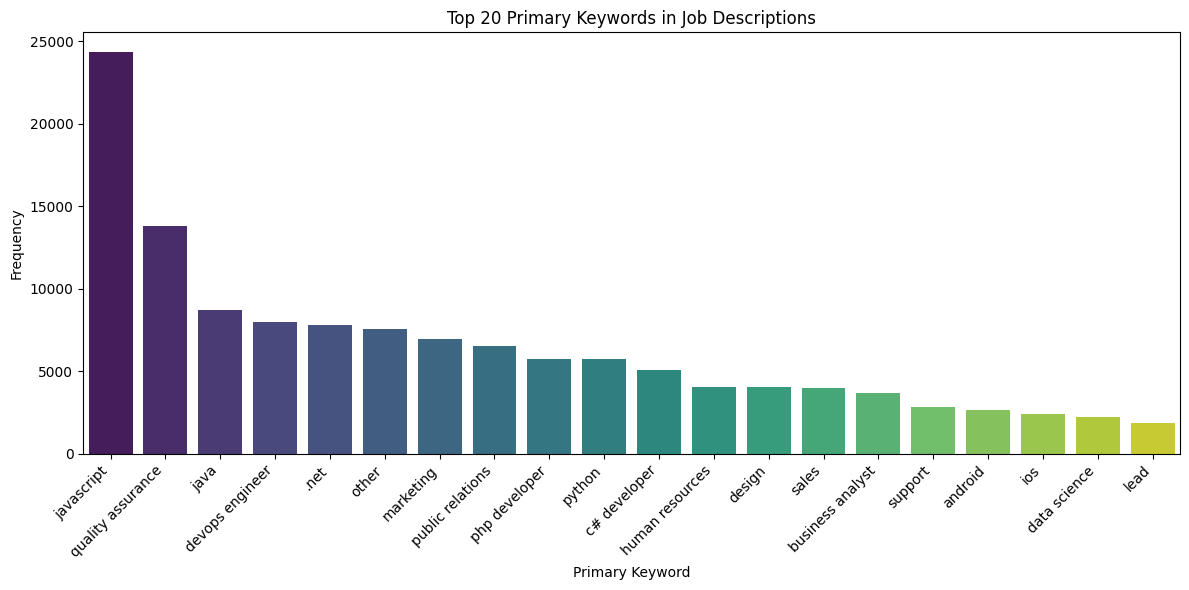

/var/folders/nh/xdbb27c93571kfy6gdhnh7wr0000gn/T/ipykernel_27165/4063234205.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_positions.index, y=top_positions.values, palette='magma')


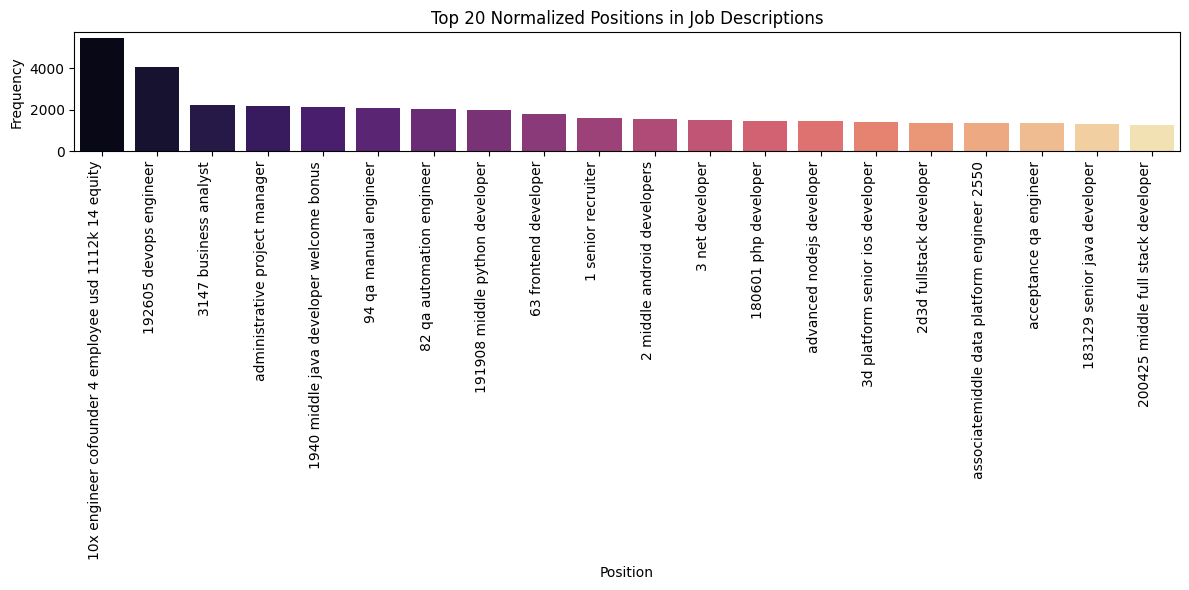

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the frequency distribution of 'Primary Keyword Normalized'
primary_keyword_counts = jobs_df_cleaned['Primary Keyword Normalized'].value_counts()

# 2. Calculate the frequency distribution of 'Position Normalized'
position_counts = jobs_df_cleaned['Position Normalized'].value_counts()

# 3. Select the top N most frequent primary keywords and positions
top_n = 20 # Choose N
top_primary_keywords = primary_keyword_counts.nlargest(top_n)
top_positions = position_counts.nlargest(top_n)

# 4. Create bar plots to visualize the frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=top_primary_keywords.index, y=top_primary_keywords.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title(f'Top {top_n} Primary Keywords in Job Descriptions')
plt.xlabel('Primary Keyword')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=top_positions.index, y=top_positions.values, palette='magma')
plt.xticks(rotation=90, ha='right')
plt.title(f'Top {top_n} Normalized Positions in Job Descriptions')
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()